Baseline split:
baseline_group
Low (0-11 pubs)    202
Medium (12-25)     202
High (26+ pubs)    199
Name: count, dtype: int64


c:\Users\sla99\anaconda3\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
c:\Users\sla99\anaconda3\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the pointplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


<Figure size 1200x600 with 0 Axes>

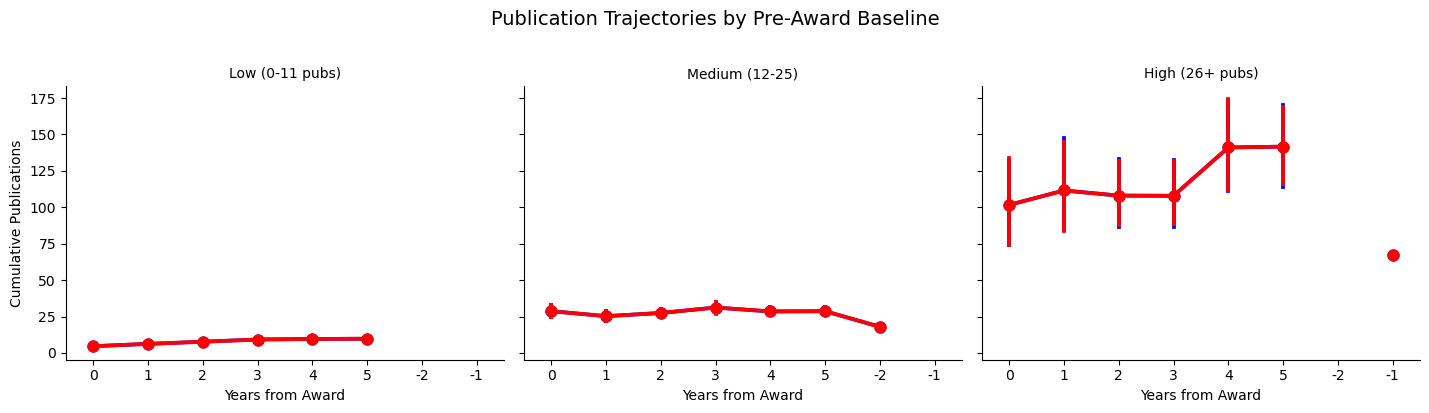


Median pubs by baseline/year:
career_age_at_award    -2    -1      0     1     2     3      4      5
baseline_group                                                        
Low (0-11 pubs)       NaN   NaN    3.0   5.0   7.0  10.0   10.0   10.0
Medium (12-25)       18.0   NaN   23.5  23.0  25.0  33.0   26.0   28.0
High (26+ pubs)       NaN  67.0  104.0  83.0  78.0  82.0  100.0  104.5


C:\Users\sla99\AppData\Local\Temp\ipykernel_17832\406155710.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = profiles.groupby(['baseline_group', 'career_age_at_award'])['total_pubs_at_award'].median().unstack()


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("..")
DATA_MATCHED = ROOT / "data" / "matched"
DATA_FIGURES = ROOT / "data" / "figures"

# Load treated juniors
profiles = pd.read_csv(DATA_MATCHED / "junior_authors_all_conferences.csv")

# Baseline tertiles (pre-award pubs)
profiles['baseline_group'] = pd.qcut(profiles['total_pubs_at_award'], 3, 
                                     labels=['Low (0-11 pubs)', 'Medium (12-25)', 'High (26+ pubs)'])

print("Baseline split:")
print(profiles['baseline_group'].value_counts().sort_index())

# Award year = career_age_at_award (relative year 0)
plt.figure(figsize=(12, 6))
g = sns.FacetGrid(profiles, col='baseline_group', col_wrap=3, height=4, aspect=1.2)
g.map(sns.pointplot, 'career_age_at_award', 'total_pubs_at_award', color='blue')
g.map(sns.pointplot, 'career_age_at_award', 'total_pubs_at_award', markers='o', color='red')  # Duplicate for line
g.set_axis_labels("Years from Award", "Cumulative Publications")
g.set_titles(col_template="{col_name}")
g.fig.suptitle("Publication Trajectories by Pre-Award Baseline", y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(DATA_FIGURES / "20_baseline_trajectories.png", dpi=150, bbox_inches='tight')
plt.show()

# Save table
summary = profiles.groupby(['baseline_group', 'career_age_at_award'])['total_pubs_at_award'].median().unstack()
summary.to_csv(DATA_FIGURES / "20_baseline_summary.csv")
print("\nMedian pubs by baseline/year:")
print(summary.round(1))


**Pre-Award Heterogeneity** (Figure): Award effects vary sharply by baseline productivity. High-productivity juniors (>25 pubs pre-award) accelerate post-award, while low-productivity peers (<11 pubs) remain flat. No evidence of convergence - awards reinforce existing trajectories (Matthew Effect).
